# Pipeline evaluation — Architecture A vs Architecture B

This notebook assembles the two complete pipelines from the models saved in notebooks 01 and 02, runs them on the held-out test set, and compares them.

- **Pipeline A**: Stage 1A (ham | not_normal) → Stage 2A (spam | phishing)
- **Pipeline B**: Stage 1B (phishing | not_phishing) → Stage 2B (ham | spam)

Primary metrics: accuracy and macro F1. Secondary: phishing→ham count (phishing messages that slipped through undetected).

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, os

from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

BASE = "../.."

In [35]:
test   = pd.read_csv(f"{BASE}/data/processed/07/test_data.csv")
X_test = test["message"]
y_test = test["label"]

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

m = f"{BASE}/models/07"
s1a_model = load_pkl(f"{m}/stage1a_model.pkl")
s1a_vec   = load_pkl(f"{m}/stage1a_vectorizer.pkl")
s2a_model = load_pkl(f"{m}/stage2a_model.pkl")
s2a_vec   = load_pkl(f"{m}/stage2a_vectorizer.pkl")

s1b_model = load_pkl(f"{m}/stage1b_model.pkl")
s1b_vec   = load_pkl(f"{m}/stage1b_vectorizer.pkl")
s2b_model = load_pkl(f"{m}/stage2b_model.pkl")
s2b_vec   = load_pkl(f"{m}/stage2b_vectorizer.pkl")

print("Pipeline A — Stage 1A:", type(s1a_model).__name__, "| Stage 2A:", type(s2a_model).__name__)
print("Pipeline B — Stage 1B:", type(s1b_model).__name__, "| Stage 2B:", type(s2b_model).__name__)

Pipeline A — Stage 1A: LogisticRegression | Stage 2A: LogisticRegression
Pipeline B — Stage 1B: LogisticRegression | Stage 2B: LogisticRegression


In [36]:
def predict_pipeline_a(messages, s1_model, s1_vec, s2_model, s2_vec):
    """Architecture A: ham | not_normal → spam | phishing."""
    messages = pd.Series(messages).reset_index(drop=True)
    preds    = pd.Series([None] * len(messages), dtype=object)
    s1_out   = s1_model.predict(s1_vec.transform(messages))
    preds[s1_out == "normal"] = "ham"
    idx = np.where(s1_out == "not_normal")[0]
    if len(idx) > 0:
        s2_out = s2_model.predict(s2_vec.transform(messages.iloc[idx]))
        for i, p in zip(idx, s2_out):
            preds[i] = p
    return preds.values


def predict_pipeline_b(messages, s1_model, s1_vec, s2_model, s2_vec):
    """Architecture B: phishing | not_phishing → ham | spam."""
    messages = pd.Series(messages).reset_index(drop=True)
    preds    = pd.Series([None] * len(messages), dtype=object)
    s1_out   = s1_model.predict(s1_vec.transform(messages))
    preds[s1_out == "phishing"] = "phishing"
    idx = np.where(s1_out == "not_phishing")[0]
    if len(idx) > 0:
        s2_out = s2_model.predict(s2_vec.transform(messages.iloc[idx]))
        for i, p in zip(idx, s2_out):
            preds[i] = p
    return preds.values


def phishing_leakage(y_true, y_pred):
    """Returns (total_phishing, phishing→ham, phishing→spam)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    total   = int((y_true == "phishing").sum())
    as_ham  = int(((y_true == "phishing") & (y_pred == "ham")).sum())
    as_spam = int(((y_true == "phishing") & (y_pred == "spam")).sum())
    return total, as_ham, as_spam

## Architecture A results

Stage 1A separates ham from suspicious messages; Stage 2A then classifies spam vs phishing.

In [37]:
y_pred_a = predict_pipeline_a(X_test, s1a_model, s1a_vec, s2a_model, s2a_vec)

print(f"accuracy: {accuracy_score(y_test, y_pred_a):.4f}\n")
print(classification_report(y_test, y_pred_a))

accuracy: 0.9520

              precision    recall  f1-score   support

         ham       0.97      0.97      0.97     34655
    phishing       0.85      0.89      0.87     17167
        spam       0.97      0.96      0.97     50055

    accuracy                           0.95    101877
   macro avg       0.93      0.94      0.94    101877
weighted avg       0.95      0.95      0.95    101877



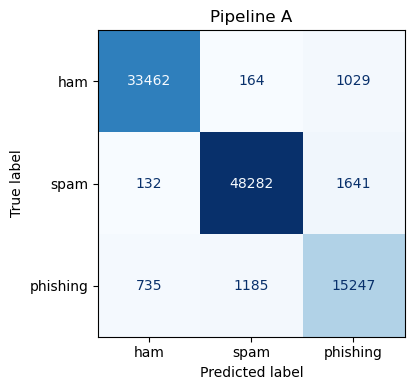

In [38]:
cm_a = confusion_matrix(y_test, y_pred_a, labels=["ham", "spam", "phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a, display_labels=["ham", "spam", "phishing"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Pipeline A")
plt.tight_layout()
plt.show()

## Architecture B results

Stage 1B separates phishing from everything else; Stage 2B then classifies ham vs spam for the remaining messages.

In [39]:
y_pred_b = predict_pipeline_b(X_test, s1b_model, s1b_vec, s2b_model, s2b_vec)

print(f"accuracy: {accuracy_score(y_test, y_pred_b):.4f}\n")
print(classification_report(y_test, y_pred_b))

accuracy: 0.9416

              precision    recall  f1-score   support

         ham       0.95      0.97      0.96     34655
    phishing       0.85      0.83      0.84     17167
        spam       0.97      0.96      0.97     50055

    accuracy                           0.94    101877
   macro avg       0.92      0.92      0.92    101877
weighted avg       0.94      0.94      0.94    101877



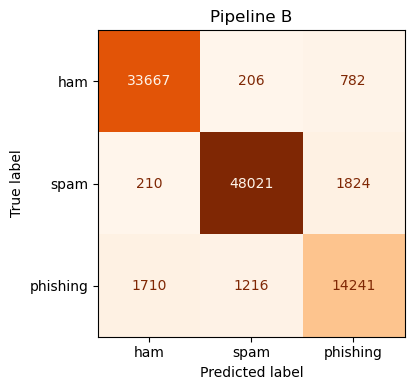

In [40]:
cm_b = confusion_matrix(y_test, y_pred_b, labels=["ham", "spam", "phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b, display_labels=["ham", "spam", "phishing"]).plot(
    ax=ax, cmap="Oranges", colorbar=False
)
ax.set_title("Pipeline B")
plt.tight_layout()
plt.show()

## Side-by-side comparison

Confusion matrices next to each other make it easier to spot where each architecture fails. The table below then puts the numbers in order: accuracy and macro F1 first, phishing→ham second.

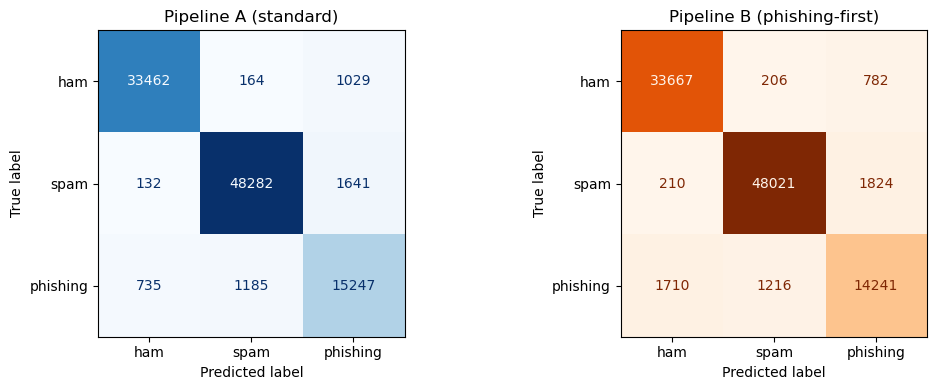

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title, cmap in zip(
    axes,
    [cm_a, cm_b],
    ["Pipeline A (standard)", "Pipeline B (phishing-first)"],
    ["Blues", "Oranges"],
):
    ConfusionMatrixDisplay(cm, display_labels=["ham", "spam", "phishing"]).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
os.makedirs(f"{BASE}/reports/figures/07", exist_ok=True)
plt.savefig(f"{BASE}/reports/figures/07/pipeline_comparison_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
rows = []
for name, y_pred in [("Architecture A", y_pred_a), ("Architecture B", y_pred_b)]:
    total, as_ham, as_spam = phishing_leakage(y_test, y_pred)
    rows.append({
        "pipeline":        name,
        "accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "macro_f1":        round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "phishing_recall": round(recall_score(y_test, y_pred, labels=["phishing"], average="micro", zero_division=0), 4),
        "phishing→ham":    as_ham,
        "ph→ham %":        round(100 * as_ham / total, 1),
        "phishing→spam":   as_spam,
    })

summary = pd.DataFrame(rows).set_index("pipeline")
print(summary.to_string())

metrics = summary.to_dict(orient="index")
os.makedirs(f"{BASE}/data/processed/07", exist_ok=True)
with open(f"{BASE}/data/processed/07/arch_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nsaved arch_metrics.json")

                accuracy  macro_f1  phishing_recall  phishing→ham  ph→ham %  phishing→spam
pipeline                                                                                  
Architecture A    0.9520    0.9360           0.8882           735       4.3           1185
Architecture B    0.9416    0.9204           0.8296          1710      10.0           1216

saved arch_metrics.json
